In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import os
from pylab import *
mpl.rcParams['font.sans-serif'] = ['SimHei']

In [3]:
# 小盘：2.5-20 亿$
# 中盘：20-100 亿$
# 蓝筹：>100 亿$
# ---------------------------
# 1) 股票分组
# ---------------------------
AI_max = ["MSFT", "GOOGL", "META", "AMZN", "TSLA", "ORCL", "CRM", "ADBE"]
AI_mid = ["SNOW", "PLTR", "DDOG", "MDB", "U", "CRWD", "ZS", "NET"]
AI_min = ["AI", "BBAI", "SOUN", "VERI", "UPST", "CXAI"]

finance_max = ["JPM", "BAC", "WFC", "C", "GS", "MS", "AXP", "BLK", "SCHW"]
finance_mid = ["USB", "PNC", "TFC", "COF", "STT", "BK", "MTB", "FITB", "CFG"]
finance_min = ["HOOD", "SOFI", "AFRM", "LC", "MQ", "NU", "HIPO", "ROOT"]

encryption_max = ["COIN", "MSTR", "MARA", "RIOT", "CLSK", "HUT", "HIVE", "BITF"]
encryption_mid = ["CIFR", "WULF", "IREN", "BTBT", "CORZ", "BKKT", "BTDR"]
encryption_min = ["ANY", "ARBK", "ABTC", "GREE", "BTCS"]

semiconductor_max = ["NVDA", "AMD", "INTC", "AVGO", "QCOM", "TXN", "ADI", "MU", "NXPI", "TSM"]
semiconductor_mid = ["MCHP", "MPWR", "ON", "LRCX", "KLAC", "TER", "GFS"]
semiconductor_min = ["AEHR", "NVTS", "INDI", "LASR", "HIMX", "SMTC", "AMBA", "POWI"]

In [4]:
proxy = 'http://127.0.0.1:7890'  # 代理设置，此处修改
os.environ['HTTP_PROXY'] = proxy
os.environ['HTTPS_PROXY'] = proxy

In [ ]:
# 彻底禁掉代理（见上一节）
for v in ("HTTP_PROXY", "HTTPS_PROXY", "http_proxy", "https_proxy"):
    os.environ.pop(v, None)

# 按照行业、盘子大小获取数据(每周)

In [5]:
# 展平去重
tickers = sorted(set(
    AI_max + AI_mid + AI_min +
    finance_max + finance_mid + finance_min +
    encryption_max + encryption_mid + encryption_min +
    semiconductor_max + semiconductor_mid + semiconductor_min
))

# ---------------------------
# 2) 下载日线（用 Adj Close 计算更稳）
#    然后转为周频并计算周涨跌幅
# ---------------------------
start_date = "2022-12-28"
end_date = "2025-12-29"  # end 是右开区间，写到 12-29 才能包含 12-28

data = yf.download(
    tickers=" ".join(tickers),
    start=start_date,
    end=end_date,
    interval="1d",
    group_by="ticker",
    auto_adjust=False,
    progress=False,
    threads=True,
)

# 取 Adj Close（若没有则退回 Close）
if isinstance(data.columns, pd.MultiIndex):
    if ("Adj Close" in data.columns.get_level_values(1)):
        px = data.xs("Adj Close", axis=1, level=1)
    else:
        px = data.xs("Close", axis=1, level=1)
else:
    # 单只股票退化情况
    col = "Adj Close" if "Adj Close" in data.columns else "Close"
    px = data[[col]].rename(columns={col: tickers[0]})

# 周频：用每周最后一个交易日的收盘（周末对齐）
px_w = px.resample("W-FRI").last()

# 周涨跌幅：pct_change
df_stock_weekly = px_w.pct_change()

# 限定日期范围（保险）
df_stock_weekly = df_stock_weekly.loc["2022-12-28":"2025-12-28"]

# 按照行业获取ETF涨跌幅数据（每周）

In [6]:
# ---------------------------
AI_ETF = ["QQQ", "AIQ", "BOTZ"]
FIN_ETF = ["XLF", "KRE", "PSCF"]
CRYP_ETF = ["IBIT", "BLOK", "WGMI"]
SEMI_ETF = ["SMH", "SOXX", "XSD"]

etfs = sorted(set(AI_ETF + FIN_ETF + CRYP_ETF + SEMI_ETF))

In [7]:
# ---------------------------
# 2. 时间区间
# ---------------------------
start_date = "2022-12-28"
end_date = "2025-12-29"   # 右开区间，确保包含 12-28

# ---------------------------
# 3. 下载日线数据
# ---------------------------
data = yf.download(
    tickers=" ".join(etfs),
    start=start_date,
    end=end_date,
    interval="1d",
    group_by="ticker",
    auto_adjust=False,
    progress=False,
    threads=True,
)

# ---------------------------
# 4. 提取收盘价（优先 Adj Close）
# ---------------------------
if isinstance(data.columns, pd.MultiIndex):
    if "Adj Close" in data.columns.get_level_values(1):
        prices = data.xs("Adj Close", axis=1, level=1)
    else:
        prices = data.xs("Close", axis=1, level=1)
else:
    # 单 ETF 的退化情况
    col = "Adj Close" if "Adj Close" in data.columns else "Close"
    prices = data[[col]].rename(columns={col: etfs[0]})

# ---------------------------
# 5. 转周频 & 计算周涨跌幅
# ---------------------------
prices_weekly = prices.resample("W-FRI").last()
df_etf_weekly = prices_weekly.pct_change()

# 截取指定区间
df_etf_weekly = df_etf_weekly.loc["2022-12-28":"2025-12-28"]

# 以周为单位，计算每个小类涨跌幅均值，与行业ETF涨跌幅比较,进行可视化

In [8]:
# 个股分组
groups = {
    "AI": {
        "max": AI_max,
        "mid": AI_mid,
        "min": AI_min,
        "etf": ["QQQ", "AIQ", "BOTZ"]
    },
    "Finance": {
        "max": finance_max,
        "mid": finance_mid,
        "min": finance_min,
        "etf": ["XLF", "KRE", "PSCF"]
    },
    "Crypto": {
        "max": encryption_max,
        "mid": encryption_mid,
        "min": encryption_min,
        "etf": ["IBIT", "BLOK", "WGMI"]
    },
    "Semiconductor": {
        "max": semiconductor_max,
        "mid": semiconductor_mid,
        "min": semiconductor_min,
        "etf": ["SMH", "SOXX", "XSD"]
    }
}

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11724\2876929935.py:47: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\Administrator\anaconda3\envs\stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


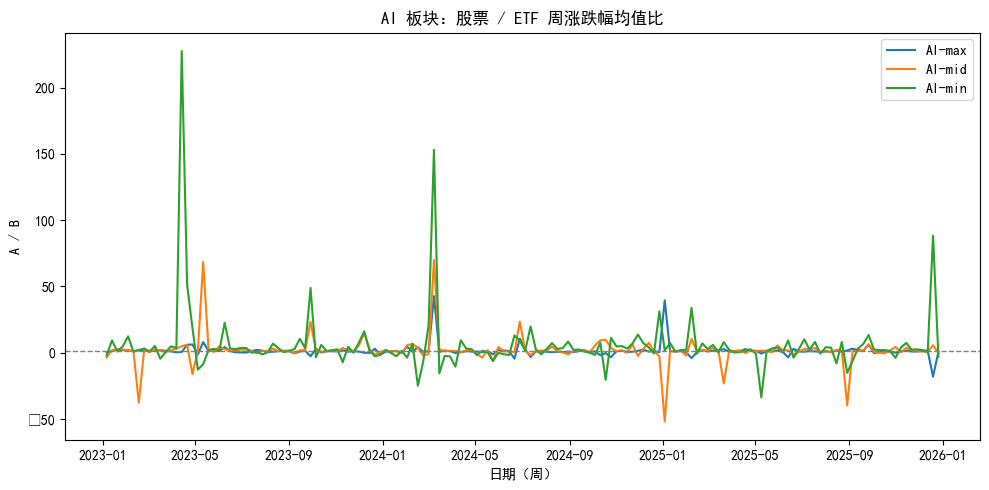

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11724\2876929935.py:47: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\Administrator\anaconda3\envs\stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


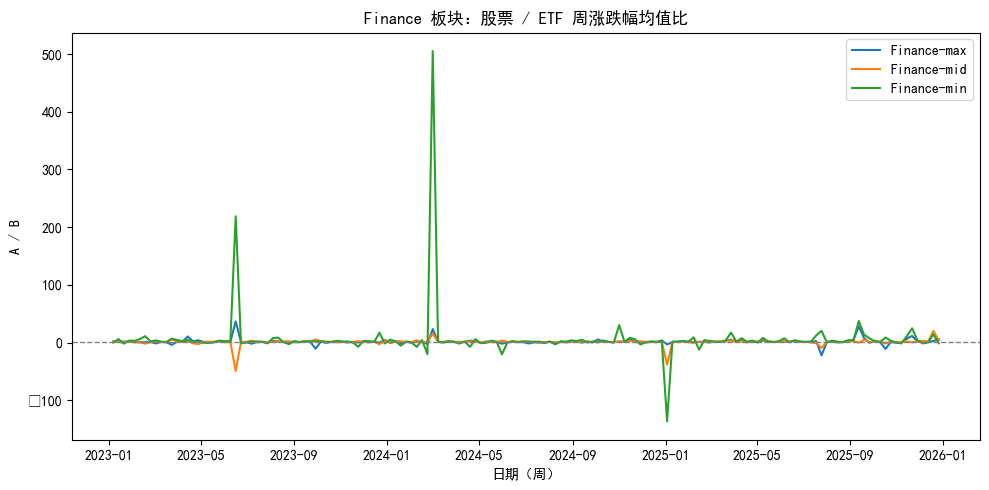

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11724\2876929935.py:47: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\Administrator\anaconda3\envs\stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


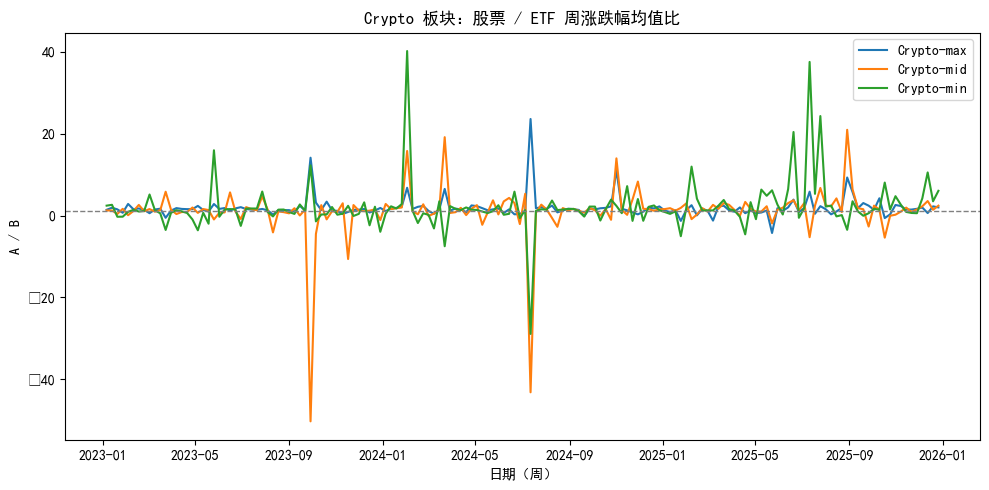

C:\Users\Administrator\AppData\Local\Temp\ipykernel_11724\2876929935.py:47: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\Administrator\anaconda3\envs\stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


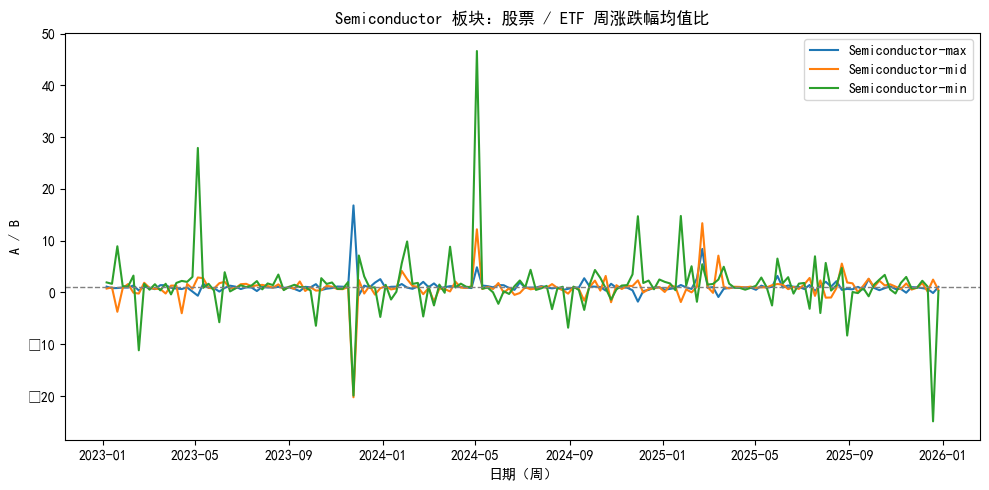

In [9]:
# =========================
# 主循环：每个行业一张图
# =========================
for sector, cfg in groups.items():

    fig, ax = plt.subplots(figsize=(10, 5))

    # ---------
    # 行业 ETF 周涨跌幅均值 B
    # ---------
    etf_cols = [c for c in cfg["etf"] if c in df_etf_weekly.columns]
    if len(etf_cols) == 0:
        print(f"{sector}: ETF 数据缺失，跳过")
        continue

    B = df_etf_weekly[etf_cols].mean(axis=1)

    # ---------
    # 三个小类：max / mid / min
    # ---------
    for size, stock_list in zip(
        ["max", "mid", "min"],
        [cfg["max"], cfg["mid"], cfg["min"]]
    ):
        stock_cols = [c for c in stock_list if c in df_stock_weekly.columns]
        if len(stock_cols) == 0:
            print(f"{sector}-{size}: 无股票数据，跳过")
            continue

        # A：该小类股票周涨跌幅均值
        A = df_stock_weekly[stock_cols].mean(axis=1)

        # A / B
        ratio = A / B

        ax.plot(
            ratio.index,
            ratio,
            label=f"{sector}-{size}"
        )

    ax.axhline(1.0, linestyle="--", color="gray", linewidth=1)
    ax.set_title(f"{sector} 板块：股票 / ETF 周涨跌幅均值比")
    ax.set_ylabel("A / B")
    ax.set_xlabel("日期（周）")
    ax.legend()
    plt.tight_layout()
    plt.show()